# (노트) Pytorch Linear Regression - 방법1
> 미완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [파이토치, 딥러닝]

### Import 

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt 

### Data

`-` model: $y_i=w_0+w_1x_i+\epsilon_i=2.5+4x_i+\epsilon_i , \quad \mbox{for } i=1,2,\dots,n $ 

`-` model: ${\bf y} = {\bf X} {\bf W} +\boldsymbol{\epsilon}$ 
 - ${\bf y}=\begin{bmatrix} y_1 \\ y_2 \\ \dots \\ y_n\end{bmatrix}, \quad  {\bf X} = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \\ .. \\ 1 & x_n \end{bmatrix}, \quad {\bf W}= \begin{bmatrix} 2.5 \\ 4 \end{bmatrix} $ 

In [2]:
n = 100 
ones = torch.ones(n)
x,_ = torch.randn(n).sort()
X = torch.vstack([ones,x]).T
W = torch.Tensor([2.5,4]) 
ϵ = torch.randn(n)*0.5

In [3]:
torch.manual_seed(43052)
y=X@W+ϵ
ytrue=X@W

- ${\bf y}={\bf X W}+\boldsymbol{\epsilon}$ 
- ${\bf y}_{\tt ture}={\bf X W}$ 

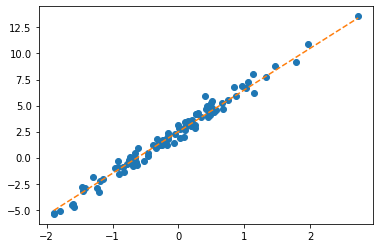

In [4]:
plt.plot(x,y,'o')
plt.plot(x,ytrue,'--')

### 학습이란? 

`-` 파란점만 주어졌다고 했을때, 주황색점들을 추론하는것. 좀 더 정확하게 말하면 given data로 $\begin{bmatrix} \hat{w}_0 \\ \hat{w}_1\end{bmatrix}$를 최대한 $\begin{bmatrix} 2.5 \\ 4 \end{bmatrix}$와 가깝게 찾는것. 

- Given data: $\big\{(1,x_i),y_i\big\}_{i=1}^{n}$

- Parameter: $\begin{bmatrix} w_0 \\ w_1\end{bmatrix}$

- Estimated parameter: $\begin{bmatrix} \hat{w}_0 \\ \hat{w}_1\end{bmatrix}$

`-` 모형을 학습한다 = 모형에 사용된 파라메터를 esimate 한다. 

### 파라메터를 학습을 하는 방법 

`-` 이론적으로 추론
    
`-` 컴퓨터의 반복계산을 이용하여 추론 (경사하강법) 

### Initial value

In [5]:
torch.manual_seed(43052)
What = torch.randn(2,requires_grad=True) # 아무거나 뿌림 

In [6]:
What

tensor([-0.8178, -0.7052], requires_grad=True)

In [7]:
yhat=X@What

In [8]:
yhat

tensor([ 0.5171,  0.5100,  0.4505,  0.3217,  0.3062,  0.3054,  0.2115,  0.2043,
         0.1805,  0.0942,  0.0534,  0.0353,  0.0235, -0.0051, -0.1378, -0.1671,
        -0.1738, -0.1816, -0.2193, -0.2310, -0.2665, -0.2901, -0.2919, -0.2989,
        -0.3054, -0.3258, -0.3480, -0.3484, -0.3492, -0.3626, -0.3779, -0.3801,
        -0.4475, -0.4882, -0.4885, -0.5399, -0.5614, -0.5753, -0.5817, -0.5910,
        -0.5929, -0.6167, -0.6408, -0.6447, -0.6469, -0.6503, -0.6840, -0.6958,
        -0.7010, -0.7033, -0.7081, -0.7710, -0.7796, -0.8076, -0.8193, -0.8319,
        -0.8386, -0.8748, -0.8827, -0.8854, -0.8862, -0.9049, -0.9166, -0.9568,
        -0.9619, -0.9784, -0.9943, -0.9982, -1.0066, -1.0084, -1.0320, -1.0627,
        -1.1039, -1.1135, -1.1189, -1.1300, -1.1321, -1.1556, -1.1584, -1.1619,
        -1.1714, -1.1786, -1.1965, -1.2012, -1.2234, -1.2868, -1.2915, -1.3475,
        -1.4073, -1.4345, -1.4983, -1.5408, -1.5618, -1.6147, -1.6264, -1.7549,
        -1.8529, -2.0781, -2.2067, -2.74

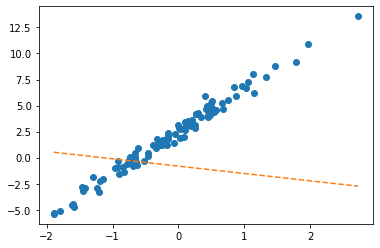

In [9]:
plt.plot(x,y,'o')
plt.plot(x,yhat.data,'--')

### One iteration

In [10]:
loss=torch.mean((y-yhat)**2) # np.mean() 하면 에러난다. 
print(loss)

tensor(24.9516, grad_fn=<MeanBackward0>)


In [11]:
loss.backward()

In [12]:
What,What.data

(tensor([-0.8178, -0.7052], requires_grad=True), tensor([-0.8178, -0.7052]))

In [13]:
What.grad.data

tensor([-5.5217, -6.3903])

`-` $loss(w_0,w_1)=(y-\hat{y})^\top (y-\hat{y})=(y-XW)^\top(y-XW)$

`-` $\frac{\partial}{\partial W}loss(w_0,w_1)= - 2X^\top y +2X^\top  X W $

In [14]:
-2 * X.T @ y + 2 * X.T @ X @ What

tensor([-552.1732, -639.0341], grad_fn=<AddBackward0>)

`-` 결과를 보니까 $loss(w_0,w_1)=\frac{1}{n}(y-\hat{y})^\top (y-\hat{y})=\frac{1}{n}(y-XW)^\top(y-XW)$ 인듯.. 

In [15]:
learning_rate = 0.1
learning_rate * What.grad.data

tensor([-0.5522, -0.6390])

In [16]:
What.data=What.data - learning_rate * What.grad.data #파라메터의 개선 
What.data

tensor([-0.2656, -0.0661])

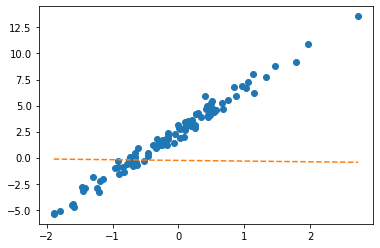

In [17]:
yhat=X @ What
plt.plot(x,y,'o')
plt.plot(x,yhat.data,'--')

In [18]:
losses=[]
yhats=[]

In [19]:
losses.append(loss.item())

In [20]:
losses

[24.951589584350586]

### Learn (=estimate $\hat{\bf W}$)

In [21]:
learning_rate = 0.1
for epoc in range(30):
    What.grad = None
    yhat=X@What
    loss=torch.mean((y-yhat)**2)
    loss.backward()
    What.data=What.data - learning_rate * What.grad.data
    losses.append(loss.item())
    yhats=yhats+[yhat.data]

In [22]:
What.data

tensor([2.5294, 4.0691])

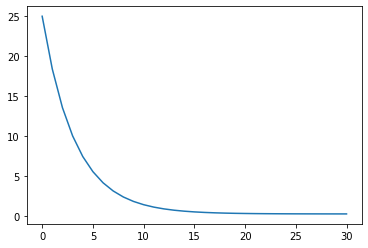

In [23]:
plt.plot(losses)

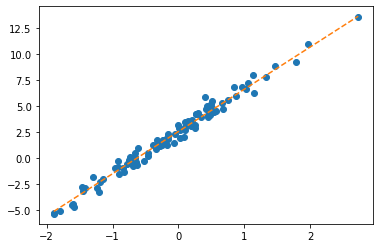

In [24]:
plt.plot(x,y,'o')
plt.plot(x,yhats[29],'--')

### Animation

In [62]:
plt.rcParams['figure.figsize'] = (10,4)
#plt.rcParams['figure.dpi'] = 80
#plt.rcParams['savefig.dpi'] = 80
plt.rcParams["animation.html"] = "jshtml" 

In [63]:
np.arrange?

Object `np.arrange` not found.


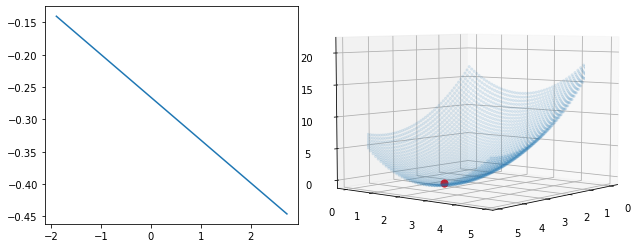

In [68]:
# Set up a figure twice as tall as it is wide
fig = plt.figure()

# First subplot
ax1 = fig.add_subplot(1, 2, 1)
# Second subplot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

## ax1
ax1.plot(x,yhats[0])

## ax2
_w0 = np.arange(0, 5, 0.1)
_w1 = np.arange(0, 5, 0.1)
w0,w1 = np.meshgrid(_w0,_w1)
l=w0*0
for i in range(len(_w0)):
    for j in range(len(_w1)):
        l[i,j]=torch.mean((y-_w0[i]-_w1[j]*x)**2)

ax2.scatter(w0, w1, l, alpha=.1,s=5)
ax2.scatter(4,2.5,torch.mean((y-2.5-4*x)**2),s=50,c='red')
ax2.azim = 40
ax2.dist = 7
ax2.elev = 5

In [75]:
from matplotlib import animation
from IPython.display import HTML

# Set up a figure twice as tall as it is wide
fig = plt.figure()

# First subplot
ax1 = fig.add_subplot(1, 2, 1)
# Second subplot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

## ax1
ax1.plot(x,y,'o')
line, = ax1.plot(x,yhats[0])
 ## ax2
_w0 = np.arange(0, 5, 0.01)
_w1 = np.arange(0, 5, 0.01)
w0,w1 = np.meshgrid(_w0,_w1)
l=w0*0
for i in range(len(_w0)):
    for j in range(len(_w1)):
        l[i,j]=torch.mean((y-_w0[i]-_w1[j]*x)**2)

ax2.scatter(w0, w1, l, alpha=.1,s=5)
ax2.azim = 40
ax2.dist = 7
ax2.elev = 5
ax2.scatter(4,2.5,torch.mean((y-2.5-4*x)**2),s=50,c='red')
sctt =ax2.scatter(4,2.5,torch.mean((y-2.5-4*x)**2),s=50,c='red')
def animate(i):
    line.set_ydata(yhats[i])
    #sctt
    return line#,sctt

ani = animation.FuncAnimation(fig, animate, frames=30)
plt.close()
ani

In [ ]:


def update_lines(num, data_lines, lines):
    for line, data in zip(lines, data_lines):
        # NOTE: there is no .set_data() for 3 dim data...
        line.set_data(data[0:2, :num])
        line.set_3d_properties(data[2, :num])
    return lines

### 로지스틱 모형 

`-` model: 

In [ ]:
πi=torch.exp(X@W)/(torch.exp(X@W)+1)

In [ ]:
np.random.binomial(n=1,p=πi,size=100)